#### 1. libraries upload

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### 2. Data load

In [2]:
churm_df= pd.read_csv('https://raw.githubusercontent.com/Haroldgio28/Probabilidad_de_impago/main/data/case%202/Churn%20Modeling.csv')
churm_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### 3. Data exploration

In [3]:
# How many dimetions churm dataframe has?
'''
Churm dataframe hast 10.000 rows and 14 columns o variables
'''
churm_df.shape


(10000, 14)

In [4]:
# Info about dataframe
'''
Info from crum dataframe shows rows number and a detailed description of it's 14 rows
it hasn't null values

'''
churm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


| Column    | Description              | Variable type | Data type |
|-----------|--------------------------|---------------|-----------|
| RowNumber | Unique id for every row  | N/A           | int       |
| CustomerId | Unique id for every customer | N/A | int |
| Surname | Surname | Qualitative nominal data | object |
| CreditScore | credit score for customer | Qantitative discrete data | int |
| Geography | Geographic location | Qualitative Nominal data | object |
| Gender | Gender | Qualitative binary data | int |
| Age | age | quantitative discrete data | int |
| Tenure | Tenure | Quantitative discrete data | int |

In [5]:
# Here we separate numeric and categorical variables from churm data
numeric_var = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
categorical_var = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited']

# now we will change data type for categorical varibales due is a good practice on data description
'''
When we change data type on a categorical variable we can choose between objet ans category
category is more efficient
'''
for categ in categorical_var:
    churm_df[categ] = churm_df[categ].astype('category')

In [6]:
churm_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  int64   
 1   CustomerId       10000 non-null  int64   
 2   Surname          10000 non-null  object  
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  category
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  int64   
 10  HasCrCard        10000 non-null  category
 11  IsActiveMember   10000 non-null  category
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  category
dtypes: category(5), float64(2), int64(6), object(1)
memory usage: 752.7+ KB


In [7]:
# We explore how many unique values calumns has
churm_df['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

In [8]:
churm_df['NumOfProducts'].unique()

array([1, 3, 2, 4])

In [9]:
churm_df['HasCrCard'].unique()

[1, 0]
Categories (2, int64): [0, 1]

In [10]:
churm_df['Exited'].unique()

[1, 0]
Categories (2, int64): [0, 1]

#### Estadistica descriptiva

In [11]:
# esta funcion nos muestra un resumen estadistico de los datos
#numericos que se ecuentran en el dataframe
churm_df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


In [12]:
# Pudo tambien hacer un describe de las variables cualitativas o categoricas
churm_df.describe(include=object)

,Surname
count,10000
unique,2932
top,Smith
freq,32


In [13]:
# con este comando puedo incluir todas las variables del dataframe para hacer el describe
churm_df.describe(include='all')

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.0,10000.000000,10000.0
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,2.0,2.0,NaN,2.0
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,1.0,1.0,NaN,0.0
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,7055.0,5151.0,NaN,7963.0
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,NaN,NaN,100090.239881,NaN
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,NaN,NaN,57510.492818,NaN
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,NaN,NaN,11.580000,NaN
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,NaN,NaN,51002.110000,NaN
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,NaN,NaN,100193.915000,NaN
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,NaN,NaN,149388.247500,NaN


### Analisis univariado

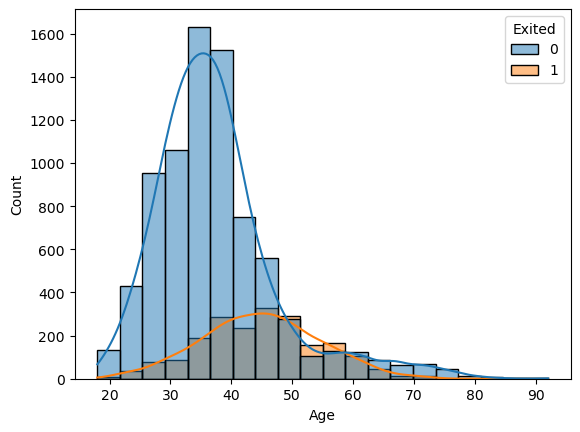

In [14]:
# para este caso vamos a iniciar con el analisis univariado utilizando seaborn
sns.histplot(
    data=churm_df,
    x = 'Age',
    kde=True,
    hue='Exited',
    bins=20
)

plt.show()

<Axes: xlabel='Age', ylabel='Density'>

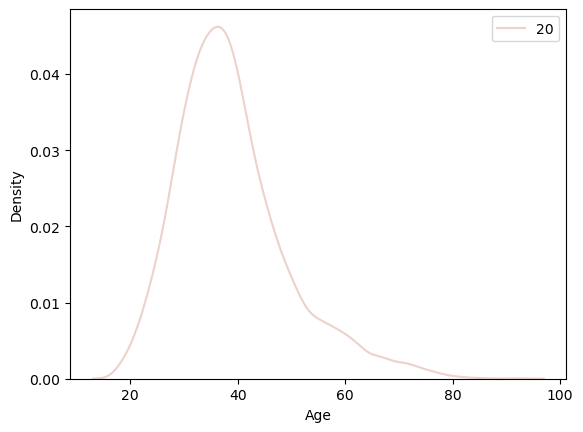

In [15]:
sns.kdeplot(
    data= churm_df,
    x = 'Age',
    hue=20,
)

In [16]:
percents = [0.05, 0.25, 0.5, 0.75, 0.95]
results = churm_df['Age'].quantile(percents)
results

0.05    25.0
0.25    32.0
0.50    37.0
0.75    44.0
0.95    60.0
Name: Age, dtype: float64

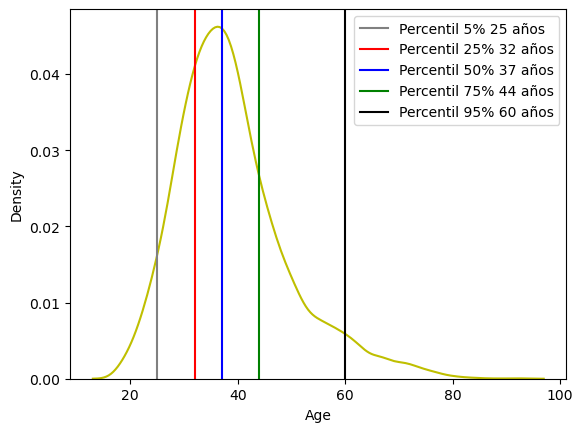

In [17]:
sns.kdeplot(
    data=churm_df,
    x= 'Age',
    color= 'y'
)

# asignacion de colores

color = {
    0.05 : 'gray',
    0.25 : 'r',
    0.5 : 'b',
    0.75 : 'g',
    0.95 : 'black'
}

for r in percents:
    plt.axvline(
        x = results[r],
        color = color[r],
        label = f'Percentil {int(r*100)}% {int(results[r])} años'
    )

plt.legend()

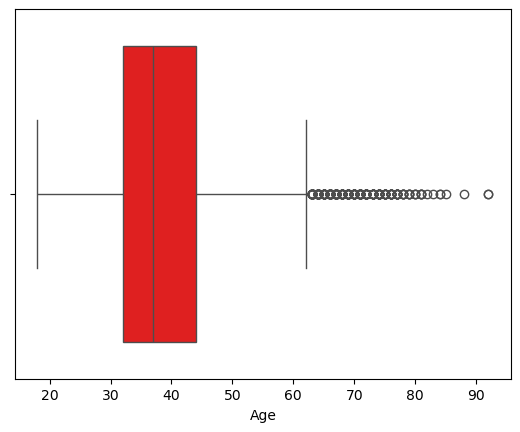

In [18]:
# Box plot

sns.boxplot(
    data= churm_df,
    x= 'Age',
    color='r'
)
plt.show()

### Count plots

Se utiliza SOLO para variables categoricas

<Axes: xlabel='Geography', ylabel='count'>

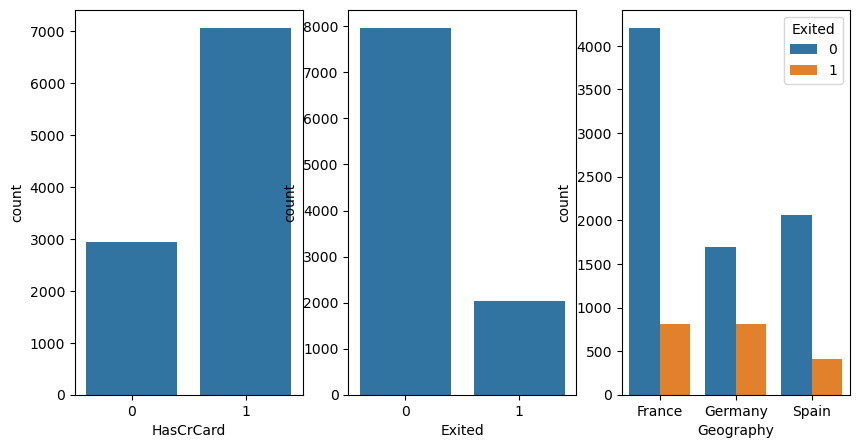

In [19]:
fig, axis = plt.subplots(1,3, figsize=(10,5))

sns.countplot(
    data= churm_df,
    x= 'HasCrCard',
    ax=axis[0]
)

sns.countplot(
    data= churm_df,
    x= 'Exited',
    ax=axis[1]
)

sns.countplot(
    data= churm_df,
    x= 'Geography',
    ax=axis[2],
    hue= 'Exited'
)

### Analisis multivariable

Scatterplot, es una grafica que enfrenta a dos variables en un lienzo, donde cada uno se ubica en un punto

<Axes: xlabel='Age', ylabel='CreditScore'>

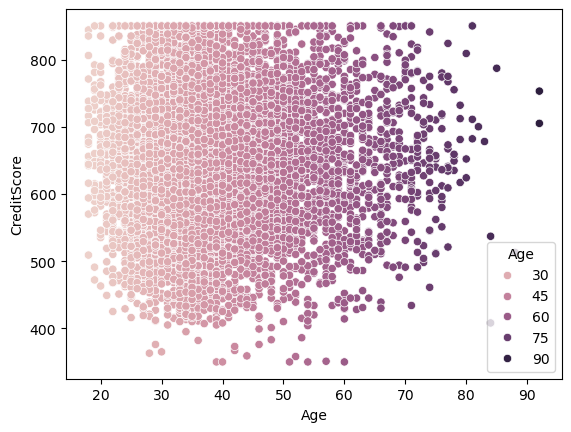

In [20]:
sns.scatterplot(
    data= churm_df,
    x='Age',
    y='CreditScore',
    hue='Age'
)

### Joinplot

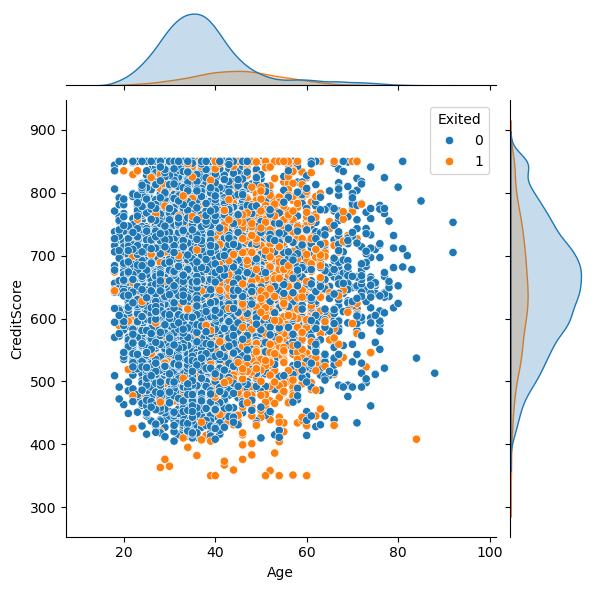

In [21]:
sns.jointplot(
    data= churm_df,
    x= 'Age',
    y='CreditScore',
    hue='Exited'
)

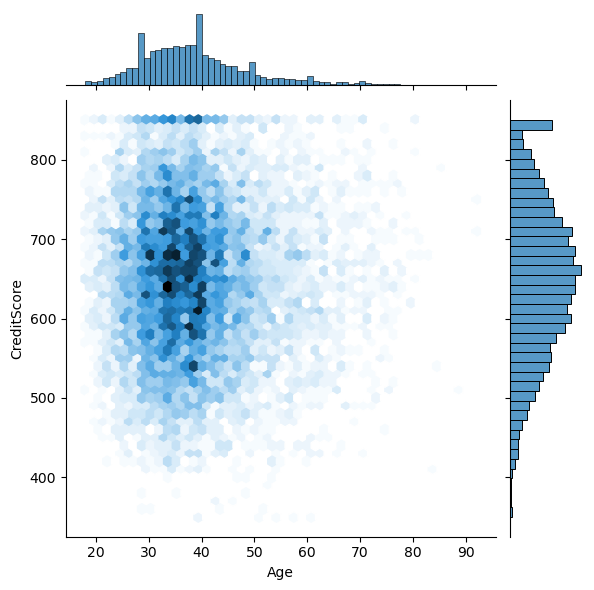

In [22]:
sns.jointplot(
    data= churm_df,
    x= 'Age',
    y='CreditScore',
    #hue='Exited',
    kind='hex'
)

### Boxplot

En este caso se utilizara multiples boxplot para poder hacer una mejor comparacion entre variables

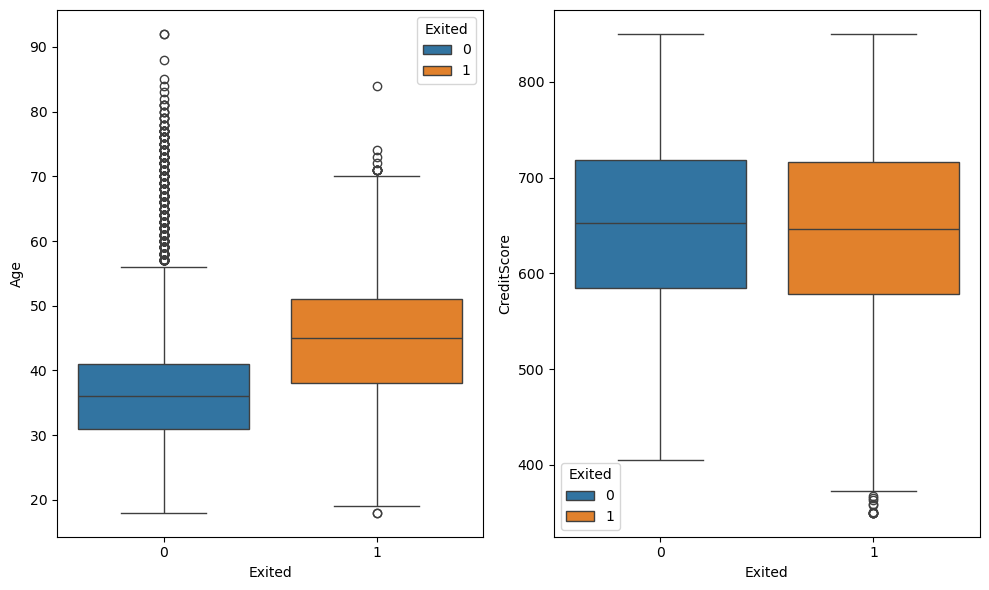

In [23]:
fig, axis = plt.subplots(1,2, figsize=(10,6))

sns.boxplot(
    data= churm_df,
    y= 'Age',
    x= 'Exited',
    hue= 'Exited',
    ax= axis[0]
)

sns.boxplot(
    data= churm_df,
    y = 'CreditScore',
    x = 'Exited',
    hue= 'Exited',
    ax = axis[1]
)

plt.tight_layout()

In [24]:
# analisis por valor de exited

churm_df.groupby('Exited')[['Age', 'CreditScore']].mean()

C:\Users\Hugo\AppData\Local\Temp\ipykernel_14640\1943198764.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churm_df.groupby('Exited')[['Age', 'CreditScore']].mean()


,Age,CreditScore
Exited,,
0,37.408389,651.853196
1,44.837997,645.351497


<Axes: xlabel='Exited', ylabel='Age'>

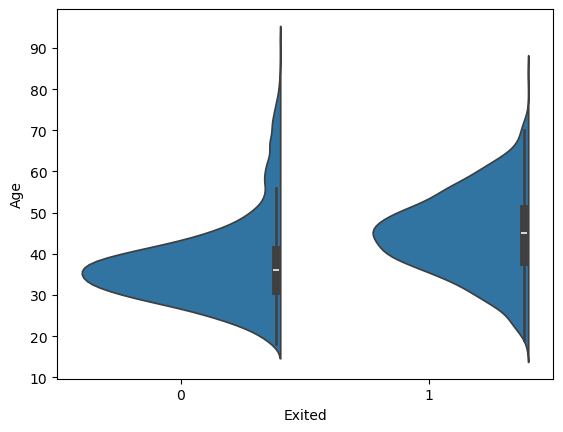

In [25]:
# Grafica tipo violin

sns.violinplot(
    data= churm_df,
    y= 'Age',
    x= 'Exited',
    split= True
)

### Tablas cruzadas y mapas de calor

Es una forma de resumir  y visualizar la relacion entre dos variables CATEGORICAS

In [26]:
df_cross = pd.crosstab(
    churm_df['Geography'],
    churm_df['Exited'],
    normalize='index' # column and all
)

df_cross

Exited,0,1
Geography,,
France,0.838452,0.161548
Germany,0.675568,0.324432
Spain,0.833266,0.166734


<Axes: xlabel='Exited', ylabel='Geography'>

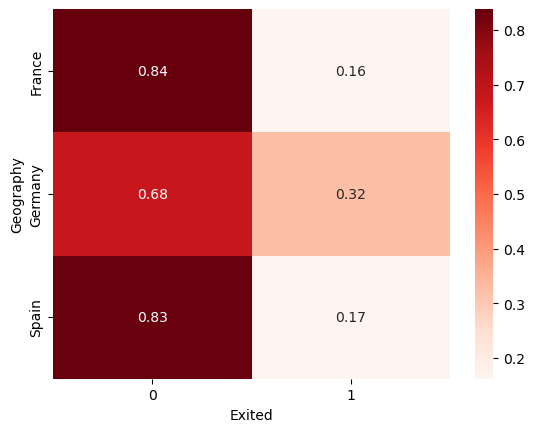

In [27]:
sns.heatmap(
    data= df_cross,
    cmap='Reds',
    annot= True
)

<Axes: xlabel='Age', ylabel='Count'>

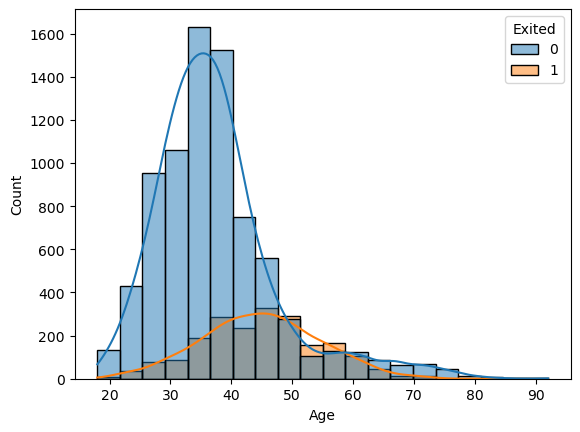

In [28]:
sns.histplot(
    data= churm_df,
    x='Age',
    bins=20,
    hue='Exited',
    kde= True
)

## Pillow

Como una primera aproximacion con el EDA de los datos podemos hacer un reporte utilizando la biblioteca de pandas profilling

In [29]:
!pip install --upgrade pip

  Using cached pip-26.0.1-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-26.0.1-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Hugo\anaconda3\python.exe -m pip install --upgrade pip


In [30]:
!pip install --upgrade Pillow

In [31]:
!pip install fastcore -U

In [32]:
!pip install ydata-profiling

In [33]:
pip install -U ydata-profiling


Note: you may need to restart the kernel to use updated packages.


In [34]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    churm_df,
    title="Churn en la banca"
)
profile.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 14/14 [00:00<00:00, 379.38it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [35]:
%pip install sweetviz

Note: you may need to restart the kernel to use updated packages.


                                             |          | [  0%]   00:00 -> (? left)

AttributeError: module 'numpy' has no attribute 'VisibleDeprecationWarning'

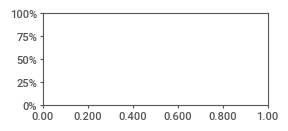

In [36]:
import sweetviz as sv

report = sv.analyze(churm_df)
report.show_html("report.html")
